In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Basic Usage

In [2]:
from torchpenny import QLayer
import pennylane as qml
import torch

Quantum Layer without any input and parameters.

In [3]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)
    def inner_gates(self, x=None):
        # You can define Pennylane circuit inside here.
        for w in range(self.wires):
            qml.Hadamard(wires=w)
            qml.PauliX(wires=w)
        qml.CNOT([0, 1])
    def measurement(self):
        return qml.probs()


In [4]:
quantum_layer = QuantumLayer(wires=3)

In [5]:
quantum_layer

QuantumLayer[Qnode, wires=3]()

In [6]:
print(qml.draw(quantum_layer.qnode)())

0: ──H──X─╭●─┤  Probs
1: ──H──X─╰X─┤  Probs
2: ──H──X────┤  Probs


In [7]:
quantum_layer()

tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250],
       dtype=torch.float64)

---

## QSubLayer module

`QSubLayer` module is a wrapper of `Operation` or `Template` class of Pennylane framework. In Pennylane, `Template` class also provides a block layer of quantum gates. However, their parameters are given by user and external source. Users have to manage the parameter dimension data for each `Template` in the circuit. 

Meanwhile in Pytorch all `Module` class manage their own parameter automatically. The input data and inherited weight and bias are seperated. To construct complicated circuit and program. This automatic management routine has benefit for rapid prototyping.

For example, in `torchpenny` there is a `ZZfeatureMap` layer.

In [8]:
from torchpenny.lib.qlayer.features import ZZfeatureMap

In [9]:
zz_feature = ZZfeatureMap(wires=4, param_received=False)
zz_feature_p = ZZfeatureMap(wires=4, param_received=True)

In [10]:
zz_feature, zz_feature_p

(ZZfeatureMap(), ZZfeatureMap[7]())

In [11]:
zz_feature.input_dim, zz_feature_p.input_dim

(None, torch.Size([1, 7]))

In [12]:
from torchpenny.module import QLayer, QSubLayer
from torchpenny.lib.qlayer.features import ZZfeatureMap, ZfeatureMap
from torchpenny.lib.qlayer.ansatz import TwoLocalAnsatz, RealAmplitude

In [13]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)

        # Internal layer 
        self.zzf_input = ZZfeatureMap(self.wires, param_received=True)
        self.two_local1 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "linear")
        self.two_local2 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "circular", except_initial=True)

    def inner_gates(self, x):
        self.zzf_input(x, wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local1(wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local2(wires=range(self.wires))
    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]

In [14]:
qlayer = QuantumLayer(
    wires= 8, 
    q_device = "default.qubit", 
    qnode_kwargs={"diff_method": "backprop"}
    )

In [15]:
qlayer

QuantumLayer[Qnode, wires=8](
  (zzf_input): ZZfeatureMap[15]()
  (two_local1): TwoLocalAnsatz()
  (two_local2): TwoLocalAnsatz()
)

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

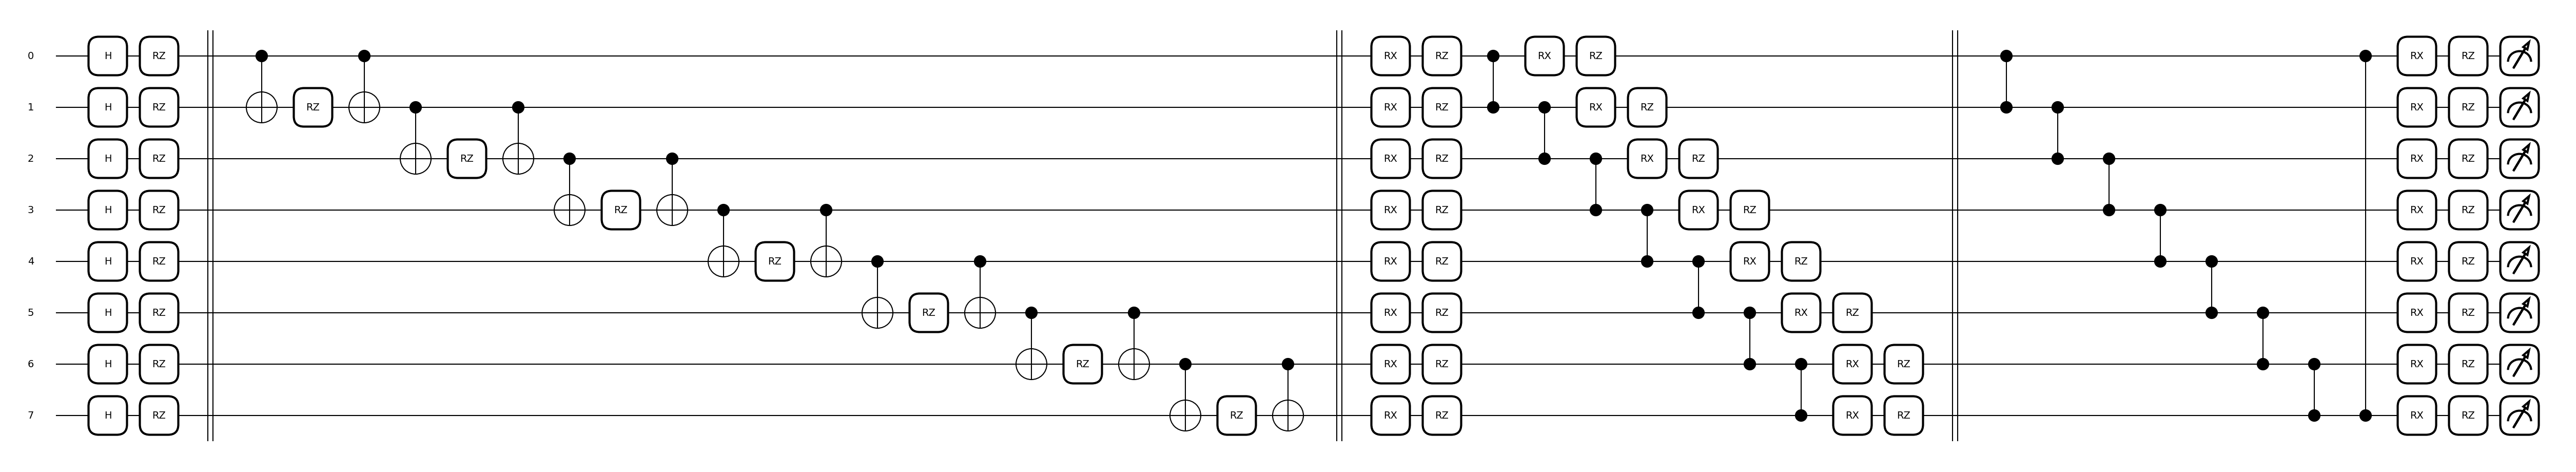

In [16]:
qml.draw_mpl(qlayer.qnode)()

In [17]:
qlayer.input_features

{'zzf_input': torch.Size([15])}

In [18]:
qlayer.zzf_input.params.shape

torch.Size([1, 15])

In [19]:
data = torch.rand((4, 15))

In [20]:
d = qlayer.qnode(data)

In [21]:
isinstance(d, torch.Tensor)

False

In [22]:
qlayer.qnode(data)

[tensor([0.4519, 0.2718, 0.0972, 0.2274], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.6179, 0.6896, 0.6670, 0.2644], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.1528, 0.1250, 0.0759, 0.0783], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.1030, 0.3818, 0.3260, 0.2837], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.2326, 0.3450, 0.3060, 0.3928], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.0386, 0.0036, 0.0213, 0.1387], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.1333, 0.0585, 0.0866, 0.1702], dtype=torch.float64,
        grad_fn=<MvBackward0>),
 tensor([0.2990, 0.1858, 0.1698, 0.1891], dtype=torch.float64,
        grad_fn=<MvBackward0>)]

In [23]:
qlayer.q_device.shots.total_shots

In [24]:
torch.stack(qlayer.qnode(data))

tensor([[0.4519, 0.2718, 0.0972, 0.2274],
        [0.6179, 0.6896, 0.6670, 0.2644],
        [0.1528, 0.1250, 0.0759, 0.0783],
        [0.1030, 0.3818, 0.3260, 0.2837],
        [0.2326, 0.3450, 0.3060, 0.3928],
        [0.0386, 0.0036, 0.0213, 0.1387],
        [0.1333, 0.0585, 0.0866, 0.1702],
        [0.2990, 0.1858, 0.1698, 0.1891]], dtype=torch.float64,
       grad_fn=<StackBackward0>)

In [25]:
result = qlayer(data)

In [26]:
result

tensor([[0.4519, 0.6179, 0.1528, 0.1030, 0.2326, 0.0386, 0.1333, 0.2990],
        [0.2718, 0.6896, 0.1250, 0.3818, 0.3450, 0.0036, 0.0585, 0.1858],
        [0.0972, 0.6670, 0.0759, 0.3260, 0.3060, 0.0213, 0.0866, 0.1698],
        [0.2274, 0.2644, 0.0783, 0.2837, 0.3928, 0.1387, 0.1702, 0.1891]],
       dtype=torch.float64, grad_fn=<ViewBackward0>)

In [ ]:
data.shape

torch.Size([4, 15])

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

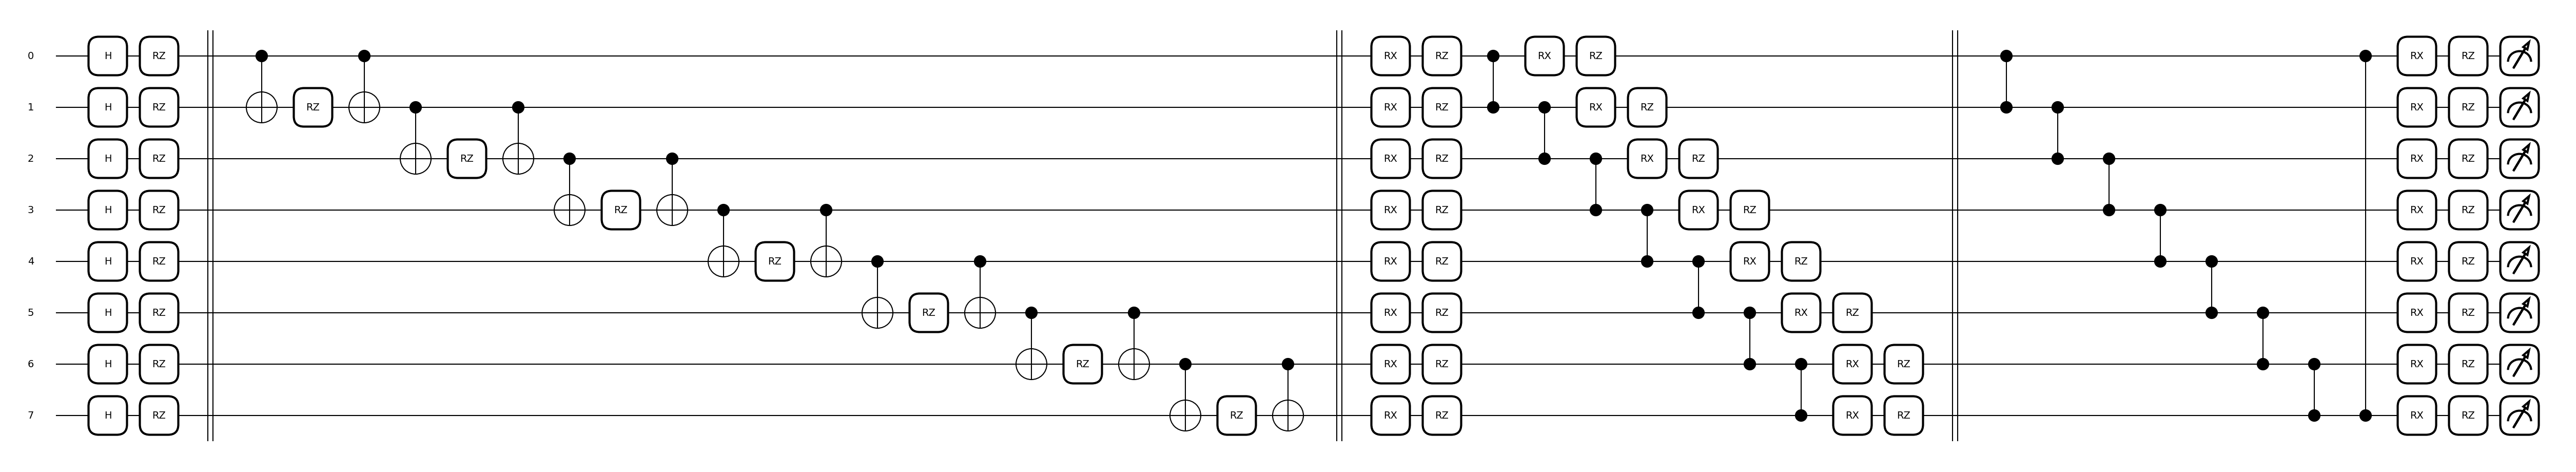

In [ ]:
qml.draw_mpl(qlayer.qnode)(data)

## QAOA example

In [27]:
from pennylane.pauli import PauliSentence, PauliWord

In [ ]:
class TrotterAnsatz(QSubLayer):
    def __init__(self, wires, ops, reps=1, order=1):
        self.ops = ops
        self.reps = reps
        self.order = order # For 2nd order Suzuki-Trotter circuit.
        super(TrotterAnsatz, self).__init__(wires, param_received=False)
    def init_weights(self):
        n = len(self.ops)
        return torch.rand(self.reps*n)

    def forward(self, wires=[], on=None):
        assert len(wires) == (self.wires), "Applied wires must be matched with the defined qubit dimension."
        
        range_wires = range(self.wires)
        n = len(self.ops)
        if on is None:
            for i in range(self.reps):
                if i!=0:
                    qml.Barrier(wires=range_wires)
                ni = n*i
                for p, pauli_word in zip(self.params[ni: ni+n], self.ops):
                    self._pauil2circuit(p, pauli_word, range_wires)
        else: # For QAOA Ansatz interface
            i = on
            ni = n*i
            for p, pauli_word in zip(self.params[ni: ni+n], self.ops):
                self._pauil2circuit(p, pauli_word, range_wires)
    
    def _pauil2circuit(self, weight, pauli:PauliWord, wires=[]):
        n = len(pauli)
        cx_map = []
        assert len(wires) >= n, f"Given Pauli word requires at least {n} wires."
        
        # Basis transformation
        for i, v in pauli.items():
            if v == "I": continue
            if v == "X":
                qml.Hadamard(i)
            elif v =="Y":
                qml.adjoint(qml.S(i))
                qml.Hadamard(i)
            cx_map.append(i)
        if len(cx_map) ==0: return None # III...III case
        w_last = cx_map[-1]
        
        del(cx_map[n-1])
        
        for cx_i in cx_map:
            qml.CNOT(wires=[wires[cx_i], w_last])
        
        qml.RZ(weight, wires=wires[w_last])
        
        for cx_i in reversed(cx_map):
            qml.CNOT(wires=[wires[cx_i], w_last])
        
        # Basis restoration
        for i, v in pauli.items():
            if v == "X":
                qml.Hadamard(i)
            elif v =="Y":
                qml.adjoint(qml.S(i))
                qml.Hadamard(i)
                
from torch.nn.parameter import Parameter         
        
class QAOAAnsatz(TrotterAnsatz):
    def __init__(self, wires, ops:PauliSentence, p=1):
        self.p = p
        super(QAOAAnsatz, self).__init__(wires, ops, reps=self.p, order=1)
        
        self.params_mixer = self._init_weights_mixer()
        
    def _init_weights_mixer(self): # Mixer weight
        n = self.p * self.wires
        return Parameter(torch.rand(n))
    
    def forward(self, wires=[]):
        for o in range(self.p):
            p_o = o*self.wires
            for i, p in enumerate(self.params_mixer[p_o: p_o + self.wires]):
                qml.RX(p, wires=i)
            super().forward(wires, on=o)
            qml.Barrier(wires=range(self.wires))
    
# Matrix to Pauli Word and sentense
class QAOA(QLayer):
    def __init__(self, ops:PauliSentence, ansatz:QSubLayer, *args, **kwargs):
        self.ops = ops
        super(QAOA, self).__init__(*args, **kwargs)
        self.ansatz = ansatz
        self._get_loss = True
    @property
    def measurement_value(self):
        return "loss" if self._get_loss else "sample"
    def expval(self):
        self._get_loss = True
    def sample(self):
        self._get_loss = False
    def inner_gates(self, x = None):
        self.ansatz(wires=range(self.wires))
    def measurement(self):
        return qml.expval(self.ops.operation()) if self._get_loss else qml.sample()

In [56]:
p1, p2, p3, p4 = PauliWord({0: "Z", 1:"Z"}), PauliWord({1: "Z", 2:"Z"}), PauliWord({2: "Z", 3:"Z"}), PauliWord({0: "Z", 3:"Z"})
Is = PauliWord({0:"I", 1:"I", 2:"I", 3:"I"})

In [88]:
ps = PauliSentence({
    Is: 2,
    p1: -0.5,
    p2: -0.5,
    p3: -0.5,
    p4: -0.5
})
print(ps)

2 * I
+ -0.5 * Z(0) @ Z(1)
+ -0.5 * Z(1) @ Z(2)
+ -0.5 * Z(2) @ Z(3)
+ -0.5 * Z(0) @ Z(3)


In [89]:
ps.operation()

(
    2 * I([0, 1, 2, 3])
  + -0.5 * (Z(0) @ Z(1))
  + -0.5 * (Z(1) @ Z(2))
  + -0.5 * (Z(2) @ Z(3))
  + -0.5 * (Z(0) @ Z(3))
)

In [90]:
t_layer = TrotterAnsatz(wires= 4, ops=ps, reps=2)
qaoa_layer = QAOAAnsatz(wires= 4, ops=ps, p=2)
qaoa = QAOA(ops=ps, ansatz=qaoa_layer, wires=4, qnode_kwargs={"diff_method":"backprop"})

In [91]:
qaoa_layer.wires, qaoa.wires

(4, 4)

In [92]:
qaoa.q_device.shots.total_shots

In [93]:
list(qaoa_layer.parameters())

[Parameter containing:
 tensor([0.3153, 0.9601, 0.9418, 0.0205, 0.8608, 0.4759, 0.3041, 0.7932, 0.9803,
         0.3372], requires_grad=True),
 Parameter containing:
 tensor([0.5728, 0.9024, 0.8297, 0.0872, 0.9189, 0.8775, 0.0215, 0.3363],
        requires_grad=True)]

(<Figure size 3100x500 with 1 Axes>, <Axes: >)

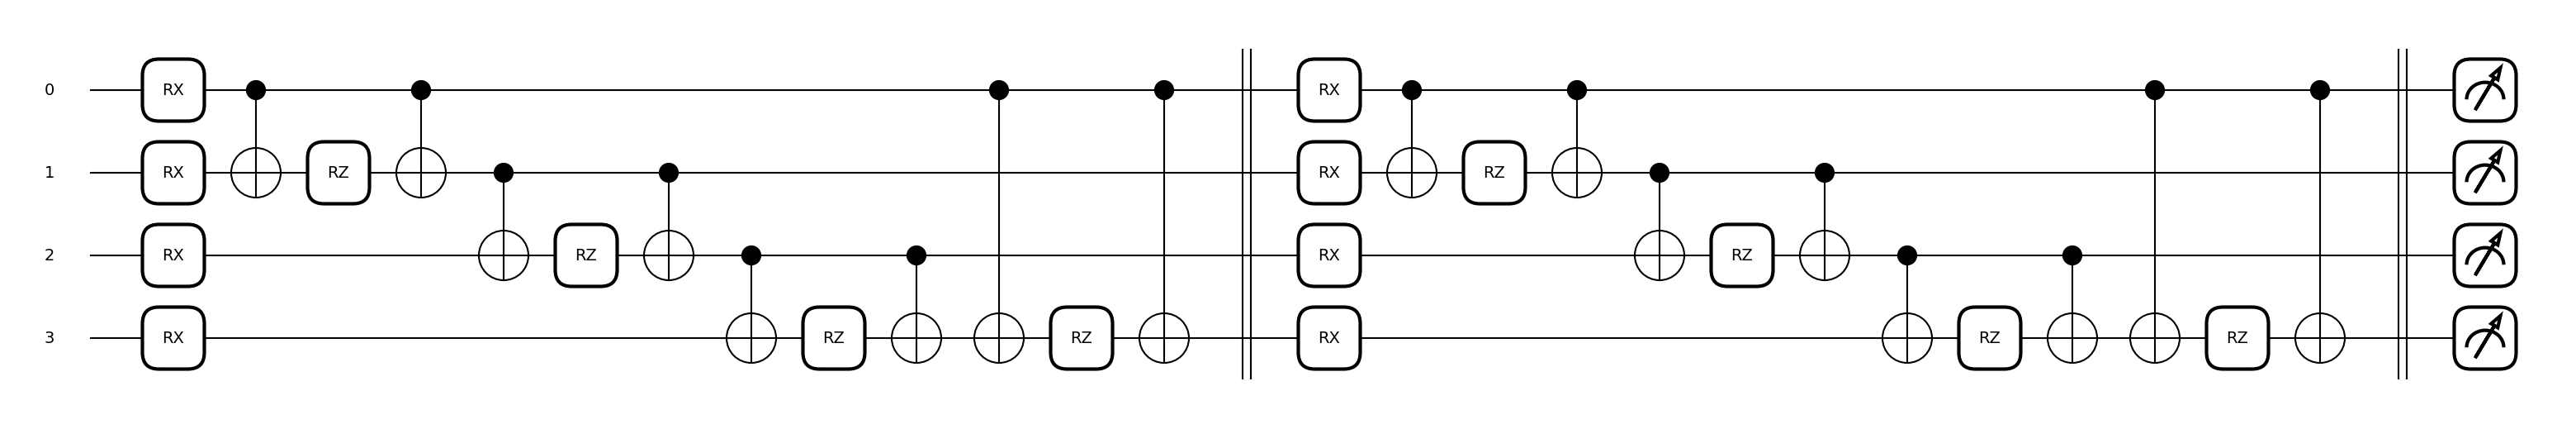

In [94]:
qml.draw_mpl(qaoa.qnode)()  

In [95]:
qaoa()

tensor(0.9838, dtype=torch.float64, grad_fn=<AddBackward0>)

In [96]:
from torch.optim import Adam

optim = Adam(qaoa.parameters(), lr = 0.001)

In [97]:
loss

tensor(2.7024e-08, dtype=torch.float64, grad_fn=<AddBackward0>)

In [98]:
epoches = 1600
loss_history = []
for e in range(epoches):
    optim.zero_grad()
    loss = qaoa()
    loss.backward()
    optim.step()
    loss_history.append(loss.item())
    print(f"{e}:\t{loss.item()}")

0:	0.983840988441874
1:	0.9807719198626239
2:	0.977705056763769
3:	0.9746401328043184
4:	0.9715785047482792
5:	0.9685185647367737
6:	0.9654610386667358
7:	0.9624066171535288
8:	0.9593549912755766
9:	0.9563058140489511
10:	0.9532599828024182
11:	0.9502165933275726
12:	0.9471771923980696
13:	0.9441404432479314
14:	0.9411070853005382
15:	0.9380768971591003
16:	0.9350505916911973
17:	0.9320278451648054
18:	0.9290087522617765
19:	0.9259934249764059
20:	0.9229817287656237
21:	0.9199742050007788
22:	0.9169707238307321
23:	0.913971187329849
24:	0.9109757525188042
25:	0.9079847859614935
26:	0.9049979126947629
27:	0.9020155000078003
28:	0.8990374515911717
29:	0.896063879811855
30:	0.8930946906073309
31:	0.8901303352868614
32:	0.8871702527065428
33:	0.8842151328533036
34:	0.881264869227036
35:	0.8783190670565193
36:	0.8753778825841328
37:	0.8724416790295728
38:	0.8695103004361067
39:	0.8665838772412384
40:	0.8636621297119847
41:	0.8607453378683839
42:	0.8578334729951445
43:	0.8549264401218858
44:

In [99]:
qaoa.measurement_value

'loss'

In [100]:
qaoa.sample()

In [101]:
qaoa.measurement_value

'sample'

In [102]:
qaoa.q_device

<default.qubit device (wires=4) at 0x24352339bb0>

In [103]:
qaoa.qnode

<QNode: device='<default.qubit device (wires=4) at 0x24352339bb0>', interface='torch', diff_method='backprop'>

In [104]:
qaoa.update_qdevice("default.qubit", q_device_kwargs={"wires": 5, "shots": 300})

In [105]:
qaoa.qnode()

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])

In [106]:
qaoa.q_device.shots.total_shots

300

In [107]:
sample = qaoa()

In [108]:
for s in sample:
    print(s)

tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0,